
## Info
- Course Index :  6.2
- URL: https://www.coursera.org/learn/ai-deep-learning-capstone/home/module/2

# PyTorch-Based Image Classifier

## Objective
- Create a PyTorch-based CNN model for classification.
- Train this model for the classification of agricultural and non-agricultural land.
- Evaluate the performance of this CNN model.

In [1]:
import os
import sys
import time
import shutil
import random
import numpy as np
import skillsnetwork
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Imported libraries")

Imported libraries


## Preparation

In [3]:
extract_dir = "./data"
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4Z1fwRR295-1O3PMQBH6Dg/images-dataSAT.tar"

#### donwload and extract

In [4]:
def check_skillnetwork_extraction(extract_dir):
    """ function to check whether data download and extraction method
    `skillsnetwork.prepare` would execute successfully, without downloading any data.
    This helps in early detection and fast fallback to explicit download and extraction
    using default libraries
    ###This is a hack for the code to run on non-cloud computing environment without errors
    """
    symlink_test = os.path.join(extract_dir, "symlink_test")
    if not os.path.exists(symlink_test):
        os.symlink(os.path.join(os.sep, "tmp"), symlink_test)
        print("Write permissions available for downloading and extracting the dataset tar file")
    os.unlink(symlink_test)

async def download_tar_dataset(url, tar_path, extract_dir):
    """function to explicitly download and extract the dataset tar file from cloud using native python libraries
    """
    if not os.path.exists(tar_path): # download only if file not downloaded already
        try:
            print(f"Downloading from {url}...")
            async with httpx.AsyncClient() as client:
                response = await client.get(url, follow_redirects=True)# Download the file asynchronously
                response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)

                with open(tar_path , "wb") as f:
                    f.write(response.content) # Save the downloaded file
                print(f"Successfully downloaded '{file_name}'.")
        except httpx.HTTPStatusError as http_err:
            print(f"HTTP error occurred during download: {http_err}")
        except Exception as download_err:
            print(f"An error occurred during the fallback process: {download_err}")
    else:
        print(f"dataset tar file already downloaded at: {tar_path}")
    with tarfile.open(tar_path, 'r:*') as tar_ref:
        tar_ref.extractall(path=extract_dir)
    print(f"Successfully extracted to '{extract_dir}'.")

In [5]:
try:
    check_skillnetwork_extraction(extract_dir)
    await skillsnetwork.prepare(url = url, path = extract_dir, overwrite = True)
except Exception as e:
    print(e)
    # --- FALLBACK METHOD FOR DOWNLOADING THE DATA ---
    print("Primary download/extration method failed.")
    print("Falling back to manual download and extraction...")

    # import libraries required for downloading and extraction
    import tarfile
    import httpx
    from pathlib import Path

    file_name = Path(url).name# Get the filename from the URL (e.g., 'data.tar')
    tar_path = os.path.join(extract_dir, file_name)
    print(f"tar_path: {os.path.exists(tar_path)} ___ {tar_path}")
    await download_tar_dataset(url, tar_path, extract_dir)

Write permissions available for downloading and extracting the dataset tar file


  0%|          | 0/6003 [00:00<?, ?it/s]

Saved to 'data'


#### Question: Why is random initialization useful for the model?

每个神经元 神经层有不同的起点， 最终有不同的表现， 如果不随机初始化，很多神经元有相同的起点 相同的输入，最后学到的都是相同的，需要更多训练才能拟合。

#### Set Seeds

- 为什么需要指定seeds?

**确保实验的可复现性（Reproducibility）**

- 作用

方便调试
公平对比

In [6]:
def set_seed(seed: int = 42) -> None:
    """Seed Python, NumPy, and PyTorch (CPU & all GPUs) and
    make cuDNN run in deterministic mode."""
    # ---- Python and NumPy -------------------------------------------
    random.seed(seed)
    np.random.seed(seed)

    # ---- PyTorch (CPU  &  GPU) --------------------------------------
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # ---- cuDNN: force repeatable convolutions -----------------------
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

In [7]:
SEED = 42
set_seed(SEED)

In [8]:
def worker_init_fn(worker_id: int) -> None:
    """Re-seed each DataLoader worker so their RNGs don't collide."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

#### 找设备 GPU

In [9]:
# 1. 检查各后端可用性
if torch.backends.mps.is_available():
    # 针对 Apple Silicon (M1/M2/M3) 的 GPU
    device = torch.device("mps")
    device_name = "MPS (Mac GPU)"
elif torch.cuda.is_available():
    # 针对 NVIDIA 的 GPU
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
else:
    # 默认使用 CPU
    device = torch.device("cpu")
    device_name = "CPU"
print(device, device_name)

mps MPS (Mac GPU)


#### Define Hyperparameters

In [10]:
dataset_path = os.path.join(extract_dir, "images_dataSAT")

In [12]:
img_size = 64
batch_size = 128
lr = 0.001
epochs = 3 # set to low number for your convenience. You can change this to any number of your liking
model_name = "ai_capstone_pytorch_state_dict.pth"
num_classes = 2 #number of classes in the dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used is {device}")

Device used is cpu


## Transforms 数据准备 数据增强

#### Task: Create the training transformation pipeline train_transform using the tranforms.Compose

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(40),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(0, shear=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#### 什么是仿射变换 (Affine)？

**通俗版：** 想象你的图片印在一块**富有弹性的方形橡胶垫**上。

- **水平/竖直翻转**：是把这块垫子**翻个面**（像照镜子或水倒影）。

- **仿射变换（特别是错切 Shear）**：是你的手按住垫子的底边，另一只手抓住顶边**平行地向左或向右拽**。


**结果：** 图片里的正方形会变成**平行四边形**。

- **它的“神”在哪？** 它虽然把图片拉斜了，但原本平行的线条（比如窗户框的两边）变换后依然是平行的。它模拟的是“侧着身子看物体”**或者**“斜着眼看东西”的感觉。

#### Task: Create the validation transformation pipeline val_transform.

In [16]:
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## Data Load

#### Task: create val_loader for the validation dataset

In [17]:
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

In [18]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

In [20]:
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=0,
                          worker_init_fn=worker_init_fn
                         )

In [23]:
val_loader = DataLoader(val_dataset,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=0,
                          worker_init_fn=worker_init_fn
                         )

MAC num_workers>0 报错

## Modeling

In [38]:
model = nn.Sequential(
                        # Conv Block 1
                        nn.Conv2d(3, 32, 5, padding=2), nn.ReLU(),
                        nn.MaxPool2d(2), nn.BatchNorm2d(32),

                        # Conv Block 2-6
                        nn.Conv2d(32, 64, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(64),
                        nn.Conv2d(64, 128, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(128),
                        nn.Conv2d(128, 256, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(256),
                        nn.Conv2d(256, 512, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(512),
                        nn.Conv2d(512, 1024, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(1024),

                        # Classifier
                        nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                        nn.Linear(1024, 2048), nn.ReLU(), nn.BatchNorm1d(2048), nn.Dropout(0.4),
                        nn.Linear(2048, num_classes)
                    ).to(device)

#### 使用nn.module定义模型

In [41]:
class ImageClassifier(nn.Module):
    def __init__(self): # 假设你之前代码中 sigmoid 对应单输出
        super(ImageClassifier, self).__init__()

        # 定义卷积块
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 5, padding=2), nn.ReLU(),
            nn.MaxPool2d(2), nn.BatchNorm2d(32),

            # Block 2
            nn.Conv2d(32, 64, 5, padding=2), nn.ReLU(),
            nn.MaxPool2d(2), nn.BatchNorm2d(64),

            # Block 3
            nn.Conv2d(64, 128, 5, padding=2), nn.ReLU(),
            nn.MaxPool2d(2), nn.BatchNorm2d(128),

            # Block 4
            nn.Conv2d(128, 256, 5, padding=2), nn.ReLU(),
            nn.MaxPool2d(2), nn.BatchNorm2d(256),

            # Block 5
            nn.Conv2d(256, 512, 5, padding=2), nn.ReLU(),
            nn.MaxPool2d(2), nn.BatchNorm2d(512),

            # Block 6
            nn.Conv2d(512, 1024, 5, padding=2), nn.ReLU(),
            nn.MaxPool2d(2), nn.BatchNorm2d(1024)
        )

        # 定义分类器块
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1024, 2048),
            nn.ReLU(),
            nn.BatchNorm1d(2048),
            nn.Dropout(0.4),
            nn.Linear(2048, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 实例化并移动到设备 (Mac GPU/MPS 或 CPU)
model = ImageClassifier().to(device)

In [42]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
best_loss = float('inf')
loss_history = {'train': [], 'val': []}
acc_history = {'train': [], 'val': []}

print("Created Model. Now training the model...")

Created Model. Now training the model...


In [43]:
for epoch in range(epochs):
    # Training Phase
    start_time = time.time() # to get the training time for each epoch
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0  # for the training metrics
    for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")):
        images, labels = images.to(device), labels.to(device)  # labels as integer class indices
        optimizer.zero_grad()
        outputs = model(images)  # outputs are raw logits
        loss = criterion(outputs, labels.long())  # criterion is nn.CrossEntropyLoss
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    # Synchronize CUDA before stopping timer (if using GPU)
    if device == 'cuda':
        torch.cuda.synchronize()

    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0 #  for the validation metrics
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Save the best model
    avg_val_loss = val_loss/len(val_loader)
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), model_name)

    # Store metrics
    loss_history['train'].append(train_loss/len(train_loader))
    loss_history['val'].append(val_loss/len(val_loader))
    acc_history['train'].append(train_correct/train_total)
    acc_history['val'].append(val_correct/val_total)

    #print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {loss_history['train'][-1]:.4f} | Val Loss: {loss_history['val'][-1]:.4f}")
    print(f"Train Acc: {acc_history['train'][-1]:.4f} | Val Acc: {acc_history['val'][-1]:.4f}")
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} training completed in {epoch_time:.2f} seconds\n")

print("Trained Model. Now evaluating the model...")

Epoch 1/3: 100%|██████████| 38/38 [01:05<00:00,  1.73s/it]


Train Loss: 0.1289 | Val Loss: 0.0293
Train Acc: 0.9642 | Val Acc: 0.9908
Epoch 1 training completed in 68.58 seconds



Epoch 2/3: 100%|██████████| 38/38 [01:00<00:00,  1.59s/it]


Train Loss: 0.0188 | Val Loss: 0.0231
Train Acc: 0.9927 | Val Acc: 0.9967
Epoch 2 training completed in 62.86 seconds



Epoch 3/3: 100%|██████████| 38/38 [00:59<00:00,  1.56s/it]


Train Loss: 0.0207 | Val Loss: 0.0133
Train Acc: 0.9923 | Val Acc: 0.9958
Epoch 3 training completed in 61.84 seconds

Trained Model. Now evaluating the model...


#### Question: What is tqdm used for?

#### tqdm是干什么用的?
"The tqdm library is used to provide a progress bar to monitor the progress of each epoch."

#### Question: Why are the train_loss, train_correct and train_total set to 0 in every epoch?

#### 为什么每epoch开始 要将train_loss, val_loss等重置为0？

如果不重置，你的损失值（Loss）会变成一个“累加值”，导致你无法判断模型是在进步还是在退步。

#### Question: Why do you need to use torch.no_grad() in the validation loop?


#### pytorch训练时 为什么在Validation阶段使用torch.no_grad()？

- 禁用梯度计算（节省内存与算力）
- 保证模型权重的“稳定性”：环境隔离
    - 计算图的残留
    - 显存溢出风险


但请注意⚠️： 即使不关闭梯度，参数也不会自动更新

## Evaluation and Visualization

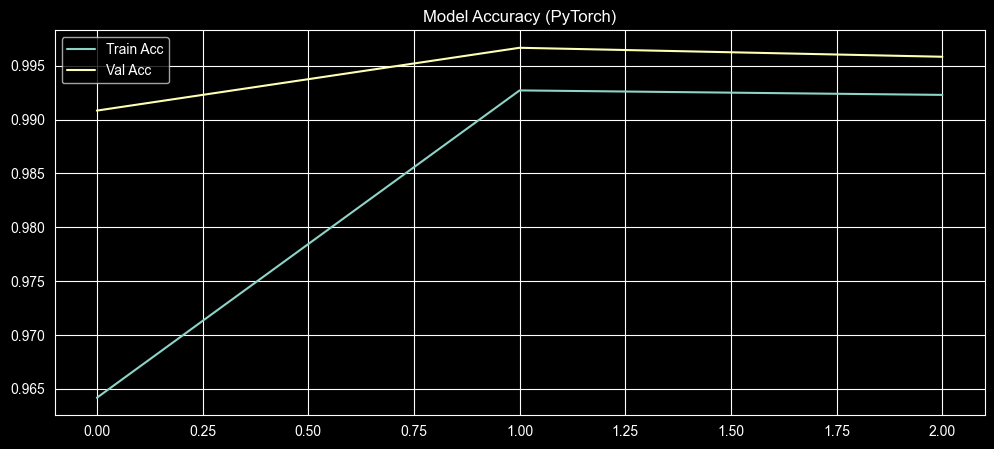

In [44]:
plt.figure(figsize=(12, 5))
plt.plot(acc_history['train'], label='Train Acc')
plt.plot(acc_history['val'], label='Val Acc')
plt.title('Model Accuracy (PyTorch)')
plt.legend()
plt.show()

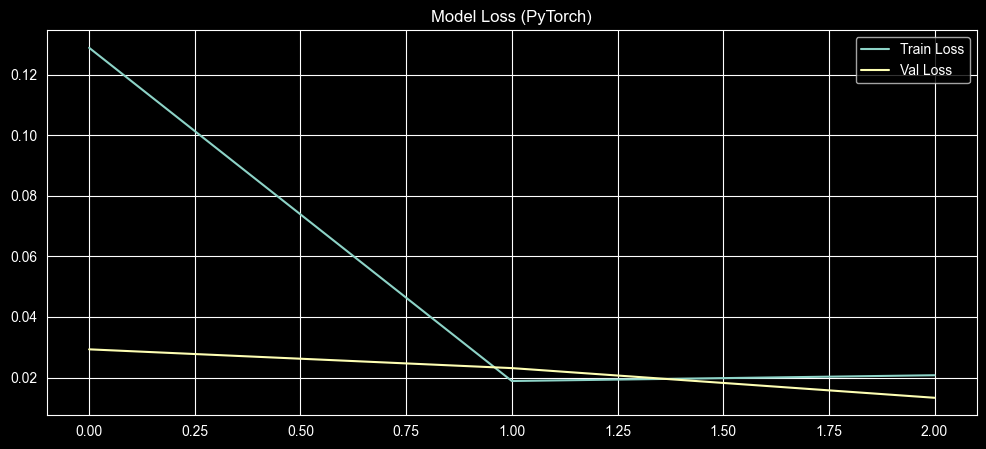

In [45]:
plt.figure(figsize=(12, 5))
plt.plot(loss_history['train'], label='Train Loss')
plt.plot(loss_history['val'], label='Val Loss')
plt.title('Model Loss (PyTorch)')
plt.legend()
plt.show()

In [46]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.numpy())

In [47]:
accuracy = accuracy_score(all_labels, all_preds)
print(f"The accuracy of the model is: {accuracy:.4f}")

The accuracy of the model is: 0.9958


#### Question: What are two different metrics on which the model can be evaluated for best performance during training?
val_loss, val_accuracy